# FT-Transformer Calibration Study — MiniBooNE Particle Identification
**Toward Robust Deep Learning: Evaluating Uncertainty in Transformer-Based Architectures for Scientific Data**

Nada Elhassan · University of Messina · ICTP Trieste, July 2026

---
### What this notebook does
1. Loads **MiniBooNE** (Fermilab neutrino detection, 130k samples, 50 features)
2. Trains an **FT-Transformer** — each feature gets its own learned projection
3. Evaluates calibration with **Standard / MC Dropout / Temperature Scaling**
4. Runs a **hyperparameter ablation** (d_model, n_layers, dropout)
5. Extracts **attention weights** to show implicit feature selection
6. Generates **7 poster-quality figures**

### Key papers
| Concept | Paper |
|---------|-------|
| FT-Transformer | Gorishniy et al. 2021 — *Revisiting Deep Learning Models for Tabular Data* · arXiv:2106.05346 |
| MC Dropout | Gal & Ghahramani 2016 — *Dropout as a Bayesian Approximation* · arXiv:1506.02142 |
| Temperature Scaling | Guo et al. 2017 — *On Calibration of Modern Neural Networks* · arXiv:1706.04599 |
| OOD / Uncertainty | Ovadia et al. 2019 — *Can You Trust Your Model's Uncertainty?* · arXiv:1906.02530 |

In [15]:
# ── CELL 1: Install & clone ──────────────────────────────────────────────────
!pip install netcal --quiet
!git clone https://github.com/nadaibrahim-png/Transformers_UQ.git 2>/dev/null || \
    (cd Transformers_UQ && git pull)
%cd Transformers_UQ
print('✓ Ready')

/content/Transformers_UQ/Transformers_UQ/Transformers_UQ/Transformers_UQ
✓ Ready


In [16]:
# ── CELL 2: Config ───────────────────────────────────────────────────────────
import config

# Dataset
config.DATASET = 'miniboone'

# Base model config (default — also used for figures 1-5)
config.D_MODEL   = 64
config.N_LAYERS  = 2
config.DROPOUT   = 0.2
config.EPOCHS    = 80
config.MC_SAMPLES = 30
config.OOD_NOISE  = 3.0

# Ablation sweep (cell 10)
config.SWEEP = {
    'd_model':  [32, 64, 128],
    'n_layers': [1, 2, 4],
    'dropout':  [0.1, 0.2, 0.3],
}
config.SWEEP_EPOCHS = 60   # fewer epochs per sweep run

print(f'Dataset  : {config.DATASET}')
print(f'd_model  : {config.D_MODEL}')
print(f'n_layers : {config.N_LAYERS}')
print(f'MC passes: {config.MC_SAMPLES}')

Dataset  : miniboone
d_model  : 64
n_layers : 2
MC passes: 30


In [17]:
# ── CELL 3: Load MiniBooNE ───────────────────────────────────────────────────
# MiniBooNE: Fermilab neutrino detection experiment
# Task: electron neutrino (signal=1) vs muon neutrino (background=0)
# 130,064 samples | 50 continuous kinematic features
import numpy as np, torch
torch.manual_seed(config.RANDOM_SEED)
np.random.seed(config.RANDOM_SEED)

from data import get_dataset, preprocess, make_ood, get_loaders

X, y, n_classes, dataset_name, feature_names = get_dataset()
(X_train, y_train), (X_val, y_val), (X_test, y_test), scaler = preprocess(X, y)
X_ood   = make_ood(X_test)
loaders = get_loaders(X_train, y_train, X_val, y_val, X_test, y_test, X_ood)

print(f'Dataset  : {dataset_name}')
print(f'Features : {X_train.shape[1]}  |  Classes: {n_classes}')
print(f'Train    : {X_train.shape[0]:,}  |  Val: {X_val.shape[0]:,}  |  Test: {X_test.shape[0]:,}')
print(f'Class balance: {y.mean():.1%} signal (νₑ), {1-y.mean():.1%} background (νμ)')


── Loading dataset: miniboone ──
  Signal (νₑ): 36,499  |  Background (νμ): 93,565
  Train: (78038, 50) | Val: (26013, 50) | Test: (26013, 50)
Dataset  : MiniBooNE Particle Identification (Fermilab)
Features : 50  |  Classes: 2
Train    : 78,038  |  Val: 26,013  |  Test: 26,013
Class balance: 28.1% signal (νₑ), 71.9% background (νμ)


In [ ]:
# ── CELL 4: Build & train FT-Transformer (base config) ───────────────────────
# FT-Transformer key difference from TabTransformer:
#   Each of the 50 features gets its OWN linear projection W_i
#   → all features become proper tokens → attention operates over all 50
# Paper: Gorishniy et al. 2021 arXiv:2106.05346
from models   import FTTransformer
from training import train

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

model = FTTransformer(n_features=X_train.shape[1], n_classes=n_classes)
print(f'Parameters: {model.count_parameters():,}')
print(f'Architecture: d_model={config.D_MODEL}, n_layers={config.N_LAYERS}, dropout={config.DROPOUT}')

history = train(model, loaders)

In [ ]:
# ── CELL 5: Standard inference (BASELINE) ────────────────────────────────────
# Dropout OFF — single forward pass — how models are typically deployed.
# Paper: Guo 2017 — 'Modern NNs are overconfident even when wrong.'
# Expected: HIGH ECE (confidence >> accuracy)
from evaluation import predict_standard, compute_all

probs_std, labels_test = predict_standard(model, loaders['test'])
metrics_std = compute_all(probs_std, labels_test)

print('── Standard Baseline ──')
print(f"Accuracy : {metrics_std['accuracy']:.4f}")
print(f"ECE      : {metrics_std['ece']:.4f}   ← should be high (overconfident)")
print(f"NLL      : {metrics_std['nll']:.4f}")

In [ ]:
# ── CELL 6: MC Dropout ───────────────────────────────────────────────────────
# Paper: Gal & Ghahramani 2016 Algorithm 1:
#   Keep dropout ON at test time. Run T=30 forward passes.
#   Predictive mean = (1/T) Σ softmax(f_dropout(x))
#   Predictive entropy H = -Σ p log p  →  high H = uncertain
#
# model.enable_mc_dropout() keeps ONLY the mc_dropout layer stochastic.
# High entropy on OOD data → model knows when it doesn't know.
from evaluation import predict_mc_dropout

probs_mc,  _, uncertainty_test = predict_mc_dropout(model, loaders['test'])
probs_mc_ood, _, uncertainty_ood = predict_mc_dropout(model, loaders['ood'])
metrics_mc = compute_all(probs_mc, labels_test)

print(f'── MC Dropout ({config.MC_SAMPLES} passes) ──')
print(f"Accuracy     : {metrics_mc['accuracy']:.4f}")
print(f"ECE          : {metrics_mc['ece']:.4f}   ← should be lower than baseline")
print(f"NLL          : {metrics_mc['nll']:.4f}")
print(f"Mean entropy IND : {uncertainty_test.mean():.4f}")
print(f"Mean entropy OOD : {uncertainty_ood.mean():.4f}  ← should be higher")

In [ ]:
# ── CELL 7: Temperature Scaling ──────────────────────────────────────────────
# Paper: Guo 2017 Section 3.3:
#   'Divide logits by scalar T, fitted on validation set.
#    T > 1 softens overconfident predictions. Accuracy unchanged.'
# Simplest possible fix: 1 parameter, no retraining.
from evaluation import TemperatureScaler, predict_temperature_scaled

ts = TemperatureScaler(model).to(DEVICE)   # move to same device as model
T_value = ts.fit(loaders['val'])

probs_ts, _ = predict_temperature_scaled(ts, loaders['test'])
metrics_ts  = compute_all(probs_ts, labels_test)

print('── Temperature Scaling ──')
print(f"Learned T : {T_value:.4f}  (>1 = was overconfident, now softened)")
print(f"Accuracy  : {metrics_ts['accuracy']:.4f}  ← unchanged from baseline")
print(f"ECE       : {metrics_ts['ece']:.4f}   ← should be lowest")
print(f"NLL       : {metrics_ts['nll']:.4f}")

In [ ]:
# ── CELL 8: Results table ─────────────────────────────────────────────────────
results = {
    'std': {'probs': probs_std,  'labels': labels_test, 'metrics': metrics_std},
    'mc':  {'probs': probs_mc,   'labels': labels_test, 'metrics': metrics_mc,
            'unc_test': uncertainty_test, 'unc_ood': uncertainty_ood},
    'ts':  {'probs': probs_ts,   'labels': labels_test, 'metrics': metrics_ts,
            'T': T_value},
}

print(f"{'='*62}")
print(f"{'CALIBRATION RESULTS — MiniBooNE (base config)':^62}")
print(f"{'='*62}")
print(f"{'Method':<28} {'Accuracy':>9} {'ECE':>9} {'NLL':>9}")
print(f"{'-'*62}")
for key, label in [('std','Standard (Baseline)'),
                   ('mc', f'MC Dropout (T={config.MC_SAMPLES})'),
                   ('ts', 'Temperature Scaling')]:
    m = results[key]['metrics']
    print(f"{label:<28} {m['accuracy']:>9.4f} {m['ece']:>9.4f} {m['nll']:>9.4f}")
print(f"{'='*62}")
print(f"Learned temperature T = {T_value:.4f}")

In [ ]:
# ── CELL 9: Generate base-config figures (fig1–fig5) ─────────────────────────
# fig1 — Reliability diagrams
# fig2 — ECE bar chart
# fig3 — Entropy: IND vs OOD
# fig4 — Results summary table
# fig5 — Training curves
import os
os.makedirs('figures', exist_ok=True)

from visualization import (plot_reliability_diagrams, plot_ece_comparison,
                            plot_entropy_ood, plot_results_table,
                            plot_training_curves)

plot_training_curves(history)
plot_reliability_diagrams(results)
plot_ece_comparison(results)
plot_entropy_ood(uncertainty_test, uncertainty_ood)
plot_results_table(results, dataset_name, T_value)

print('\n✓ Figures 1-5 saved to figures/')

In [ ]:
# ── CELL 10: Attention heatmap — implicit feature selection (fig6) ────────────
# The FT-Transformer learns which of the 50 kinematic features to attend to.
# This IS feature selection — learned end-to-end, not manual.
#
# Row 0 (CLS token) shows which features the model attends to when
# making its final prediction. High attention = feature is important.
from visualization import plot_attention_heatmap

sample_x = next(iter(loaders['test']))[0][:256].to(DEVICE)
attn_weights = model.get_attention_weights(sample_x)

print(f'Attention matrix shape: {attn_weights.shape}')
print(f'(rows = query tokens, cols = key tokens, token 0 = CLS)')

plot_attention_heatmap(attn_weights, feature_names)
print('\n✓ Figure 6 (attention heatmap) saved')

In [ ]:
# ── CELL 11: Hyperparameter ablation sweep (fig7) ────────────────────────────
# Varies d_model / n_layers / dropout one at a time.
# For EACH config: train → Standard → MC Dropout → Temperature Scaling
# Total: 9 configs × 3 methods = 27 evaluations
# Answers: which architecture produces the best-calibrated transformer?
from main import run_sweep
from visualization import plot_sweep_results

sweep_results = run_sweep(loaders, X_train.shape[1], n_classes)
plot_sweep_results(sweep_results)

print('\n✓ Figure 7 (sweep results) saved')
print('\n✓ All experiments complete!')

In [ ]:
# ── CELL 12: Download all figures to your computer ──────────────────────────
from google.colab import files
import os, glob

figure_files = sorted(glob.glob(f"{config.FIGURES_DIR}/*.png"))
print(f"Downloading {len(figure_files)} figures...")
for path in figure_files:
    files.download(path)
    print(f"  ↓ {os.path.basename(path)}")
print("Done — check your browser's downloads folder.")


---
## Extended Evaluation — 5 New Experiments

| # | Experiment | Key insight |
|---|-----------|-------------|
| 1 | Noise σ sweep | When does each method break down under shift? |
| 2 | ECE + NLL + Brier Score | Full proper-scoring-rule table |
| 3 | Attention feature importance | Which of 50 kinematic features matter most? |
| 4 | Isotonic Regression vs Temp. Scaling | Parametric vs non-parametric |
| 5 | Per-class ECE | Signal (νₑ) vs background (νμ) calibration |

EXTENDED EVALUATION — 5 experiments

[Setup] Fitting Temperature Scaler...
  Learned temperature T = 1.2824  (overconfident → softened)

[Setup] Fitting Isotonic Scaler...
  Isotonic Regression fitted on 26013 val samples (2 regressors)

[1/5] Noise sweep (σ ∈ {0, 0.5, 1.0, 2.0, 3.0})
Running noise sweep...
  σ = 0.0 | done
  σ = 0.5 | done
  σ = 1.0 | done
  σ = 2.0 | done
  σ = 3.0 | done
  Saved → figures/noise_sweep.png


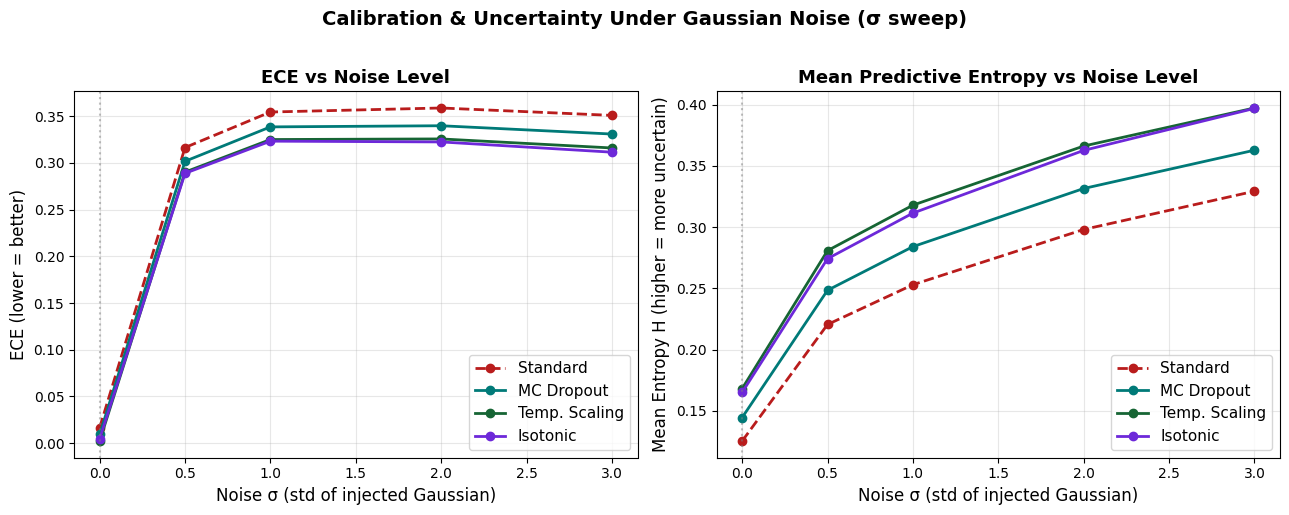


[2/5] Full metric table (ECE + NLL + Brier)
Computing full metric table...

Method                 Bal.Acc     Acc   νₑ Recall   νμ Recall      ECE      NLL    Brier
------------------------------------------------------------------------------------------
Standard                0.9229  0.9339      0.8979      0.9479   0.0163   0.1696   0.0982
MC Dropout              0.9215  0.9336      0.8938      0.9491   0.0092   0.1657   0.0972
Temp. Scaling           0.9229  0.9339      0.8979      0.9479   0.0021   0.1645   0.0970
Isotonic                0.9209  0.9336      0.8919      0.9499   0.0045   0.1672   0.0971
  Saved → figures/metrics_all.png


/content/Transformers_UQ/evaluation/extended_evaluation.py:241: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(methods, rotation=15, ha="right", fontsize=10)
/content/Transformers_UQ/evaluation/extended_evaluation.py:241: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(methods, rotation=15, ha="right", fontsize=10)
/content/Transformers_UQ/evaluation/extended_evaluation.py:241: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(methods, rotation=15, ha="right", fontsize=10)


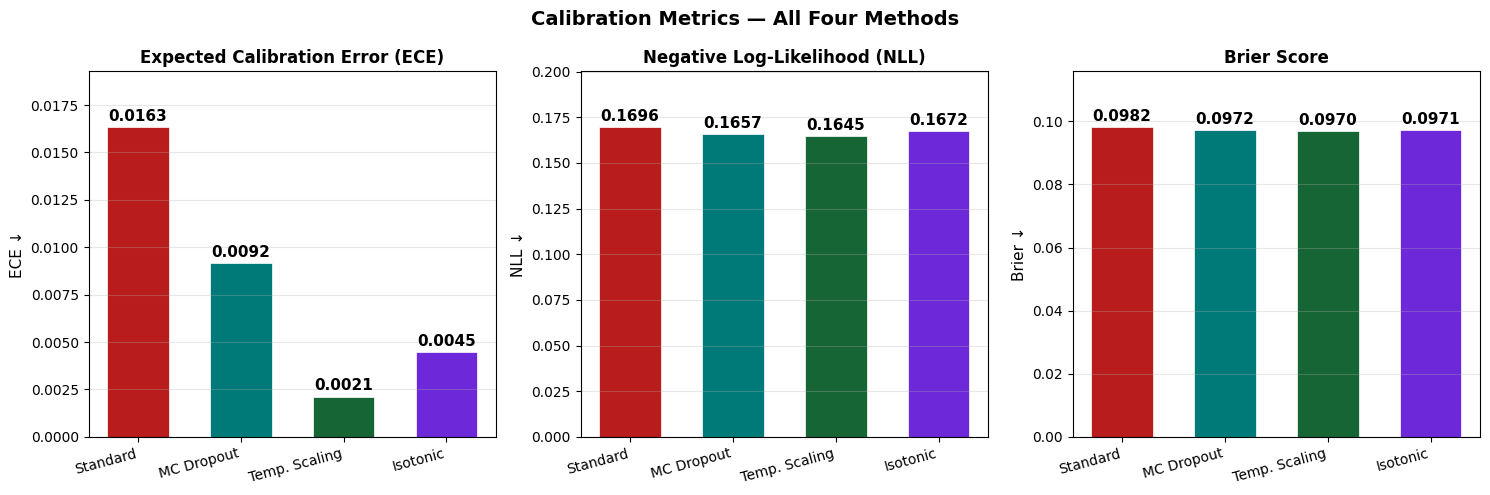


[3/5] Attention-based feature importance
Extracting attention weights...
  Saved → figures/feature_importance.png


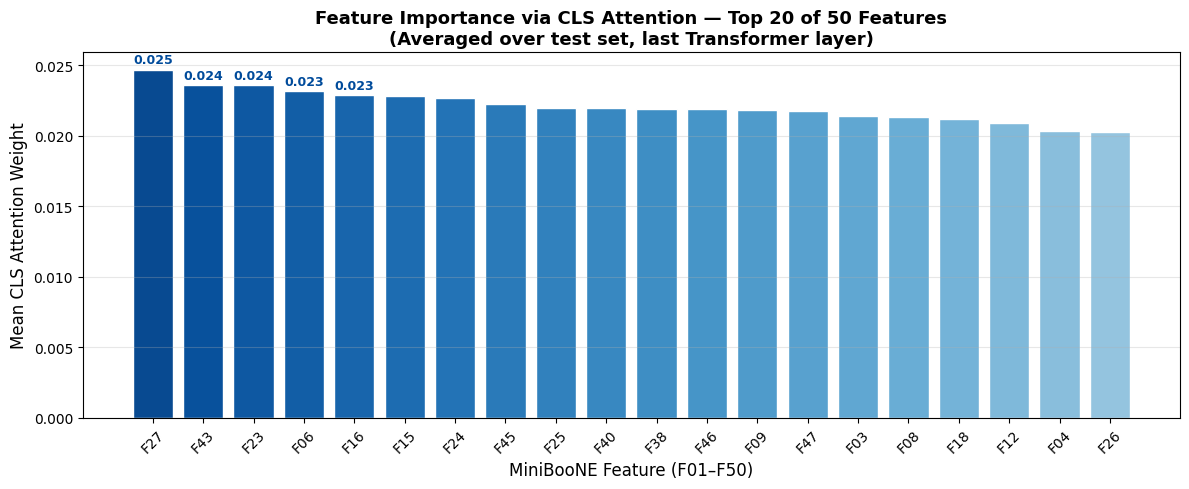


[4/5] Isotonic Regression vs Temperature Scaling
  Isotonic Regression fitted on 26013 val samples (2 regressors)
  Saved → figures/reliability_comparison.png


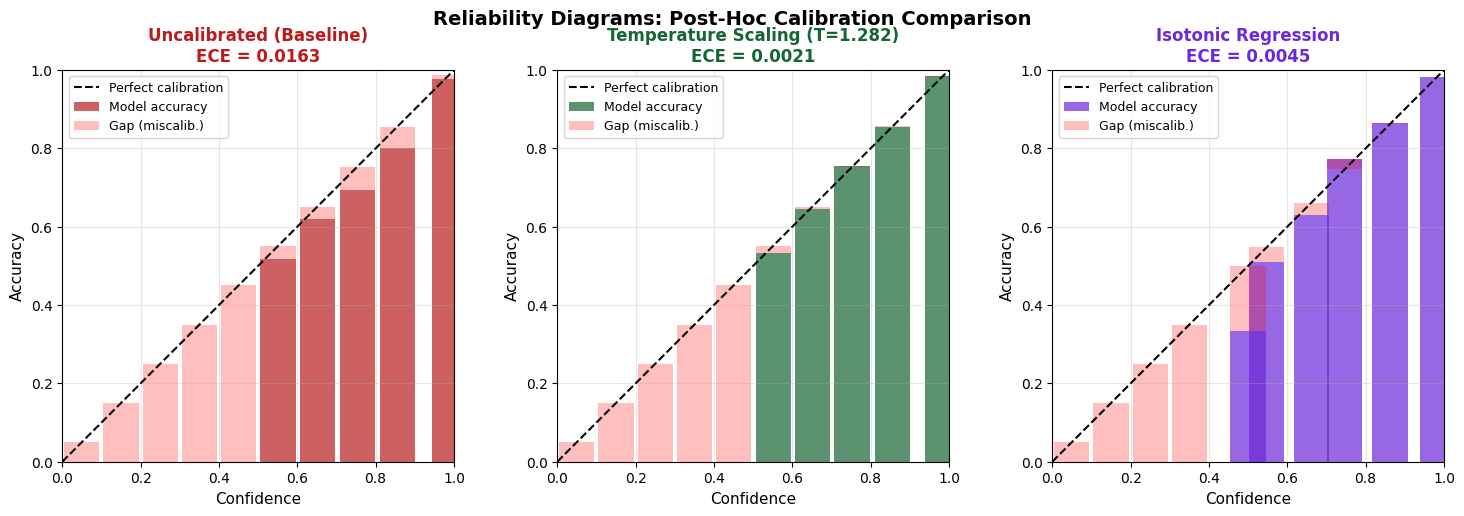


[5/5] Per-class calibration (νₑ signal vs νμ background)
Computing per-class ECE...

Method                  νμ Bkg (ECE)    νₑ Sig (ECE)
----------------------------------------------------
Standard                      0.0184          0.0118
MC Dropout                    0.0133          0.0102
Temp. Scaling                 0.0077          0.0226
Isotonic                      0.0178          0.0311
  Saved → figures/per_class_ece.png


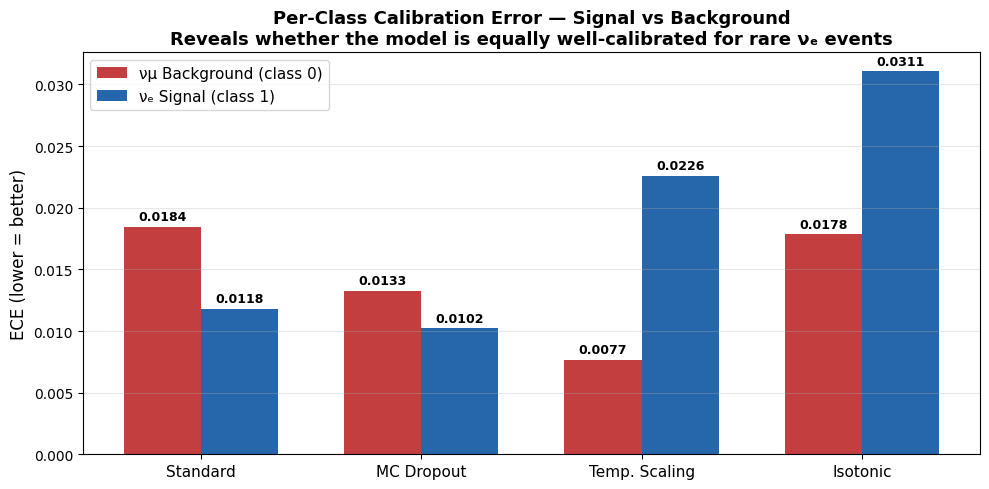


All figures saved to: figures/


In [19]:
# ── CELL 13: Run all 5 extended experiments ───────────────────────────────────
from evaluation.extended_evaluation import run_all_extended

ext_results = run_all_extended(
    model       = model,
    val_loader  = loaders["val"],
    test_loader = loaders["test"],
    figure_dir  = config.FIGURES_DIR,
)


  Learned temperature T = 1.2824  (overconfident → softened)
  Isotonic Regression fitted on 26013 val samples (2 regressors)
Running noise sweep...
  σ = 0.0 | done
  σ = 0.5 | done
  σ = 1.0 | done
  σ = 2.0 | done
  σ = 3.0 | done
  σ = 5.0 | done
  Saved → figures/noise_sweep.png


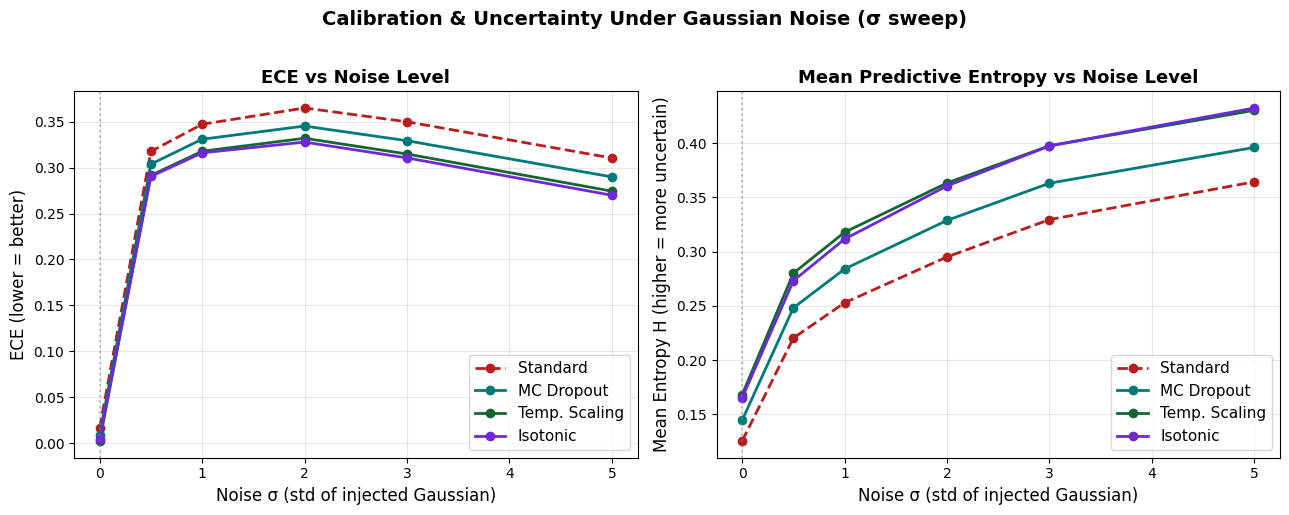

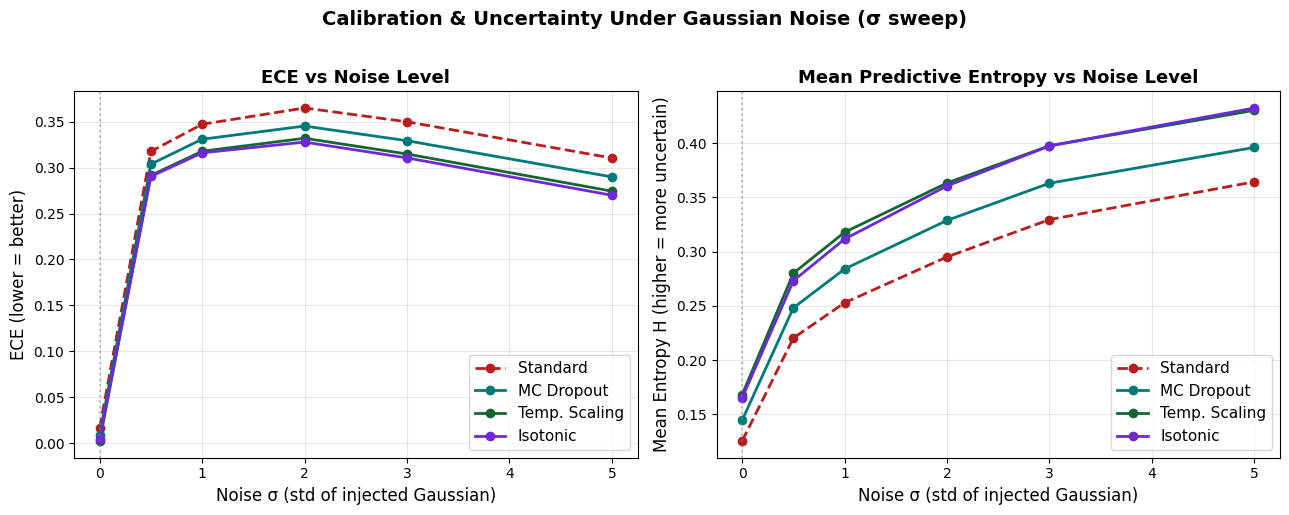

In [22]:
# ── CELL 14: Noise sweep — extend sigma range ─────────────────────────────────
from evaluation.extended_evaluation import run_noise_sweep, plot_noise_sweep
from evaluation.uncertainty import TemperatureScaler, IsotonicScaler, predict_standard

ts = TemperatureScaler(model).to(DEVICE)
ts.fit(loaders["val"])

p_val, y_val = predict_standard(model, loaders["val"])
ir = IsotonicScaler()
ir.fit(p_val, y_val)

sigmas = [0, 0.5, 1.0, 2.0, 3.0, 5.0]
s_out, s_res = run_noise_sweep(model, loaders["val"], loaders["test"], ts, ir, sigmas=sigmas)
plot_noise_sweep(s_out, s_res, save_path=f"{config.FIGURES_DIR}/noise_sweep.png")

Extracting attention weights...
  Saved → figures/feature_importance.png


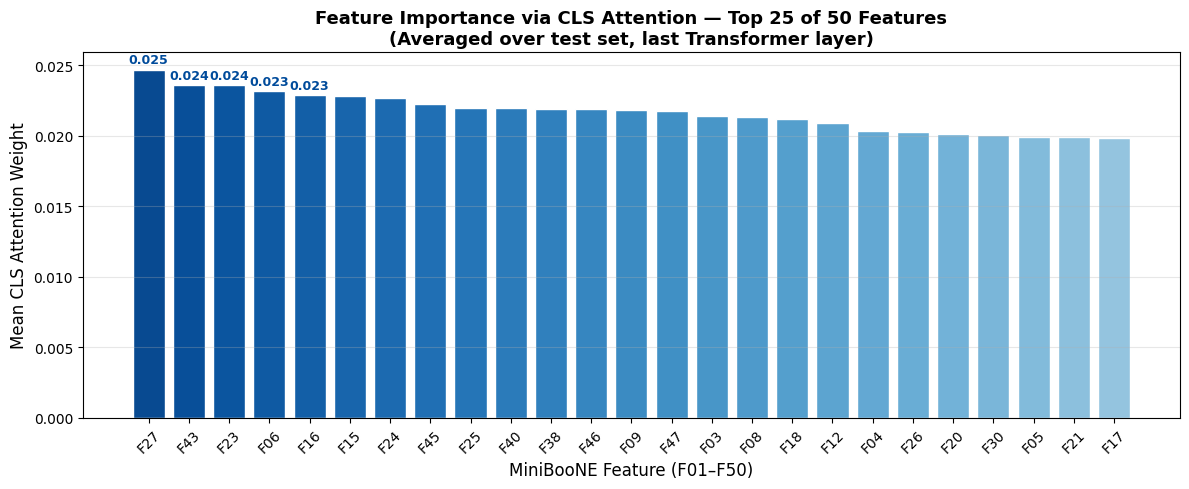

Top 10 features by CLS attention weight:
  # 1  F27  weight = 0.0247
  # 2  F43  weight = 0.0236
  # 3  F23  weight = 0.0236
  # 4  F06  weight = 0.0232
  # 5  F16  weight = 0.0229
  # 6  F15  weight = 0.0228
  # 7  F24  weight = 0.0227
  # 8  F45  weight = 0.0222
  # 9  F25  weight = 0.0220
  #10  F40  weight = 0.0220

Bottom 5 features (least attended):
  # 1  F33  weight = 0.0159
  # 2  F35  weight = 0.0158
  # 3  F28  weight = 0.0154
  # 4  F13  weight = 0.0153
  # 5  F07  weight = 0.0151


In [24]:
# ── CELL 15: Feature importance — top 25 features ────────────────────────────
from evaluation.extended_evaluation import run_feature_importance

feat_w, ranked, _ = run_feature_importance(
    model, loaders["test"], top_k=25,
    save_path=f"{config.FIGURES_DIR}/feature_importance.png"
)

print('Top 10 features by CLS attention weight:')
for rank, idx in enumerate(ranked[:10], 1):
    print(f'  #{rank:2d}  F{idx+1:02d}  weight = {feat_w[idx]:.4f}')

print('\nBottom 5 features (least attended):')
for rank, idx in enumerate(ranked[-5:], 1):
    print(f'  #{rank:2d}  F{idx+1:02d}  weight = {feat_w[idx]:.4f}')

In [25]:
# ── CELL 16: Summary table — all metrics, all methods ────────────────────────
import pandas as pd

df = pd.DataFrame(ext_results['metrics']).T
df.index.name = 'Method'
df = df[['balanced_accuracy', 'accuracy', 'signal_recall', 'background_recall', 'ece', 'nll', 'brier']]
df.columns = ['Bal. Accuracy ▲', 'Accuracy', 'νₑ Signal Recall ▲', 'νμ Bkg Recall ▲', 'ECE ▼', 'NLL ▼', 'Brier ▼']

styled = (
    df.style.format('{:.4f}')
    .highlight_max(subset=['Bal. Accuracy ▲', 'νₑ Signal Recall ▲', 'νμ Bkg Recall ▲'], color='#cce5ff')
    .highlight_min(subset=['ECE ▼', 'NLL ▼', 'Brier ▼'], color='#d4edda')
)
display(styled)

# Print physics-focused summary
print('\n=== Physics Summary ===')
for method, m in ext_results['metrics'].items():
    print(f"{method:<20}  Bal.Acc={m['balanced_accuracy']:.4f}  "
          f"νₑ Recall={m['signal_recall']:.4f}  ECE={m['ece']:.4f}")


,Bal. Accuracy ▲,Accuracy,νₑ Signal Recall ▲,νμ Bkg Recall ▲,ECE ▼,NLL ▼,Brier ▼
Method,,,,,,,
Standard,0.9229,0.9339,0.8979,0.9479,0.0163,0.1696,0.0982
MC Dropout,0.9215,0.9336,0.8938,0.9491,0.0092,0.1657,0.0972
Temp. Scaling,0.9229,0.9339,0.8979,0.9479,0.0021,0.1645,0.0970
Isotonic,0.9209,0.9336,0.8919,0.9499,0.0045,0.1672,0.0971



=== Physics Summary ===
Standard              Bal.Acc=0.9229  νₑ Recall=0.8979  ECE=0.0163
MC Dropout            Bal.Acc=0.9215  νₑ Recall=0.8938  ECE=0.0092
Temp. Scaling         Bal.Acc=0.9229  νₑ Recall=0.8979  ECE=0.0021
Isotonic              Bal.Acc=0.9209  νₑ Recall=0.8919  ECE=0.0045


In [26]:
# ── CELL 17: Download extended evaluation figures ────────────────────────────
from google.colab import files
import os, glob

# Download all figures (base + extended) in one go
all_figs = sorted(glob.glob(f"{config.FIGURES_DIR}/*.png"))
print(f"Downloading {len(all_figs)} figures...")
for path in all_figs:
    files.download(path)
    print(f"  ↓ {os.path.basename(path)}")

# Also download the notebook itself with outputs saved
print("\nDownloading notebook...")
files.download('experiment_calibration.ipynb')
print("Done — check your browser's downloads folder.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ↓ feature_importance.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ↓ reliability_comparison.png



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done — check your browser's downloads folder.
